# Chapter 8 — Factor Models: CAPM and Fama-French

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Chapter 7 turned regression into a tool with three jobs and many pitfalls. Chapter 8 puts that tool to work on the question Ch3 §3.5 deferred: *what's actually driving co-movement in our 8-asset basket, and how much "diversification" is real?* The answer in three words: **β, α, factors.**

## What we mean by "a factor model"

A factor model decomposes any asset's return into:

> total return = (β to factor 1) × (factor 1's return) + (β to factor 2) × (factor 2's return) + ... + α + ε

The flavors used in this chapter:

| Model | What it explains | Inputs |
|---|---|---|
| **CAPM** — single-factor | Market exposure only | (R<sub>i</sub> − r<sub>f</sub>), Mkt-RF |
| **Fama-French 3 (FF3)** | Market + size + value | + SMB, HML |
| **Fama-French 5 (FF5)** | + profitability + investment | + RMW, CMA |

Factor models are *just more regressors* than CAPM; the math is exactly Ch7's multiple regression.

## 1. Setup

Same 8-ticker basket as Ch3-7. **Fama-French factor data** comes from Ken French's data library at Dartmouth. We pull the daily zips directly from the Dartmouth FTP (the standard `pandas-datareader` route is broken under pandas 3.0 — the unmaintained `deprecate_kwarg` API changed). The CSVs are cached in `08-factor-models/data/`.

> **Foot-gun: Fama-French returns are reported in *percent*, not decimals.** Divide by 100 before regressing on log returns; failing this turns coefficients off by two orders of magnitude.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import urllib.request, zipfile, io
from pathlib import Path

print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"yfinance     {yf.__version__}")
import statsmodels
print(f"statsmodels  {statsmodels.__version__}")

numpy        2.4.4
pandas       3.0.2
yfinance     1.3.0
statsmodels  0.14.6


In [2]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
prices = yf.download(tickers, period="20y", auto_adjust=True, progress=False)["Close"][tickers].dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.index = log_returns.index.tz_localize(None) if log_returns.index.tz else log_returns.index
print(f"log_returns shape: {log_returns.shape}")
print(f"date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")

log_returns shape: (5030, 8)
date range: 2006-05-08 to 2026-05-05


In [3]:
def fetch_ff_csv(url, out_path):
    out_path = Path(out_path)
    if not out_path.exists():
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with urllib.request.urlopen(url) as r:
            z = zipfile.ZipFile(io.BytesIO(r.read()))
            inner = z.namelist()[0]
            text = z.read(inner).decode("latin-1")
        out_path.write_text(text)
    return out_path

def load_ff(path):
    raw = Path(path).read_text().splitlines()
    # Skip the human-readable header rows; locate the first row whose first field is YYYYMMDD.
    for i, line in enumerate(raw):
        s = line.strip()
        if s and s[0].isdigit() and "," in s:
            start = i; break
    end = len(raw)
    for j in range(start, len(raw)):
        s = raw[j].strip()
        if s == "" or "Annual" in s:
            end = j; break
    df = pd.read_csv(path, skiprows=start - 1, nrows=end - start, index_col=0)
    df.index = pd.to_datetime(df.index, format="%Y%m%d")
    df = df.apply(pd.to_numeric, errors="coerce") / 100.0  # percent -> decimal
    return df.dropna()

ff3_path = fetch_ff_csv(
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip",
    "data/ff3_daily.csv",
)
ff5_path = fetch_ff_csv(
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip",
    "data/ff5_daily.csv",
)
ff3 = load_ff(ff3_path)
ff5 = load_ff(ff5_path)

common3 = log_returns.index.intersection(ff3.index)
common5 = log_returns.index.intersection(ff5.index)
lr3 = log_returns.loc[common3]; ff3 = ff3.loc[common3]
lr5 = log_returns.loc[common5]; ff5 = ff5.loc[common5]

rf      = ff3["RF"]
mkt_rf  = ff3["Mkt-RF"]

print(f"FF3 columns: {list(ff3.columns)}")
print(f"FF5 columns: {list(ff5.columns)}")
print(f"FF aligned N: {len(common3):,}  ({common3.min().date()} -> {common3.max().date()})")

FF3 columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
FF5 columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
FF aligned N: 5,006  (2006-05-08 -> 2026-03-31)


## 2. CAPM as a single regression

CAPM says: an asset's *excess return* over the risk-free rate is proportional to the *market's excess return* plus an idiosyncratic part.

> R<sub>i,t</sub> − r<sub>f,t</sub> = α<sub>i</sub> + β<sub>i</sub>·(R<sub>mkt,t</sub> − r<sub>f,t</sub>) + ε<sub>i,t</sub>

where:
- *R<sub>i,t</sub>* — asset i's daily log return at *t*. **Units:** decimal log return.
- *r<sub>f,t</sub>* — risk-free rate at *t* (Fama-French RF, daily decimal). Same units.
- *R<sub>mkt,t</sub>* — the value-weighted CRSP US market portfolio. *Not* SPY — see §2.1 sanity check.
- *β<sub>i</sub>* — slope on the market excess return; the systematic-risk loading. Dimensionless.
- *α<sub>i</sub>* — intercept; "everything else" — average daily excess return *not* explained by market exposure.
- *ε<sub>i,t</sub>* — idiosyncratic residual at *t*.

We regress on `Mkt-RF` directly (which is already R_mkt − r_f).

In [4]:
rows = []
for t in tickers:
    excess_y = (lr3[t] - rf).values
    X = sm.add_constant(mkt_rf.values)
    f = sm.OLS(excess_y, X).fit()
    rows.append({
        "asset":     t,
        "beta":      f.params[1],
        "t(beta)":   f.tvalues[1],
        "alpha_ann": f.params[0] * 252,
        "t(alpha)":  f.tvalues[0],
        "p(alpha)":  f.pvalues[0],
        "R^2":       f.rsquared,
    })
capm = pd.DataFrame(rows).set_index("asset")
print(capm.round({"beta": 3, "t(beta)": 1, "alpha_ann": 4, "t(alpha)": 2, "p(alpha)": 3, "R^2": 3}))

        beta  t(beta)  alpha_ann  t(alpha)  p(alpha)    R^2
asset                                                      
SPY    0.974    533.1    -0.0184     -3.21     0.001  0.983
TLT   -0.237    -23.4     0.0414      1.30     0.194  0.099
GLD    0.055      4.2     0.0708      1.73     0.084  0.004
XLK    1.062    163.1     0.0125      0.61     0.542  0.842
XLF    1.276    112.3    -0.0994     -2.78     0.005  0.716
XLE    1.107     74.5    -0.0644     -1.38     0.169  0.526
XLV    0.683     92.9     0.0089      0.38     0.701  0.633
XLU    0.598     57.0     0.0093      0.28     0.778  0.393


### 2.1 SPY ≠ the market exactly

SPY's CAPM regression on Mkt-RF doesn't give β = 1 and α = 0 *exactly* — β ≈ 0.97 and α ≈ −1.8% annualized with t ≈ −3.2 (statistically distinguishable from zero!). The discrepancy is real and informative:

- **SPY** is the SPDR S&P 500 ETF — value-weighted across the *largest 500* US firms, with a small expense ratio.
- **Mkt-RF** is the value-weighted *full* CRSP US universe minus the risk-free rate — covers the entire investable US equity market, no expense ratio.

Over 20 years of daily data, the gap between "S&P 500 large caps" and "all of US equities" plus the SPY expense ratio (about 9 bps) compounds to a small but t-distinguishable α under CAPM. **This is the first lesson: even the simplest sanity check reminds us SPY is a market *proxy*, not the market.** For practical work it's close enough; for academic factor-pricing tests, use Mkt-RF directly.

### 2.2 Reading the CAPM table

β̂ for the basket sorts roughly by sector exposure:

- **TLT** β ≈ −0.24 — bonds move *opposite* the equity market on most days (the Ch3 SPY/TLT story).
- **GLD** β ≈ +0.06 — gold is essentially uncorrelated with equity at the daily level (R² < 1%).
- **XLU, XLV** β ≈ 0.6, 0.7 — defensive sectors; lower equity exposure than the broad market.
- **SPY, XLK, XLE** β ≈ 1.0–1.1 — broadly market-tracking with mild tilts.
- **XLF** β ≈ 1.28 — financials are the highest-β sector in the basket; biggest both directions.

**The α column is the headline.** Most α̂ are small with wide CIs — but **two assets are statistically distinguishable from zero at 95%**: SPY (negative, see §2.1 — partly an artifact of the SPY-vs-CRSP gap) and **XLF (negative; t ≈ −2.8)**. Financials *underperformed* the market on a β-adjusted basis — even though their high β meant they outperformed in raw returns during equity bull runs, they paid a heavy CAPM-α-negative price for the 2008 collapse.

## 3. Reading β — what the number means in dollars

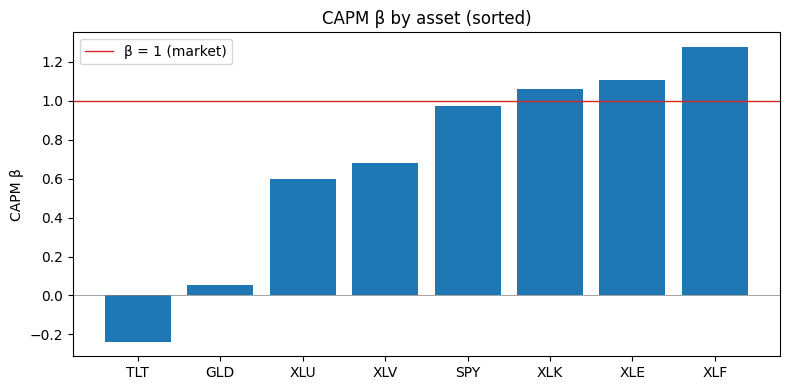

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
order = capm["beta"].sort_values().index
ax.bar(order, capm.loc[order, "beta"])
ax.axhline(1.0, color="C3", lw=1, label="β = 1 (market)")
ax.axhline(0.0, color="gray", lw=0.5)
ax.set_ylabel("CAPM β"); ax.set_title("CAPM β by asset (sorted)")
ax.legend(); fig.tight_layout(); plt.show()

**β = 1.0** — asset moves with the market 1-for-1. A $100k position gains/loses ~$1,000 on a 1% market move.
**β = 0.5** — $100k position gains/loses ~$500. Half the systematic exposure.
**β = 1.5** — $100k position gains/loses ~$1,500. Half again as much.
**β < 0** — rare for equities; common for bonds in some windows (the Ch3 SPY/TLT story; TLT here is β = −0.24).

> **Foot-gun:** β captures only *systematic* moves — whole-market days. On idiosyncratic days, all bets are off. That's the residual ε.

## 4. Reading α — the noise problem

α̂ is the regression intercept: average daily excess return *not* explained by market exposure. Its 95% CI is what determines whether we should believe it.

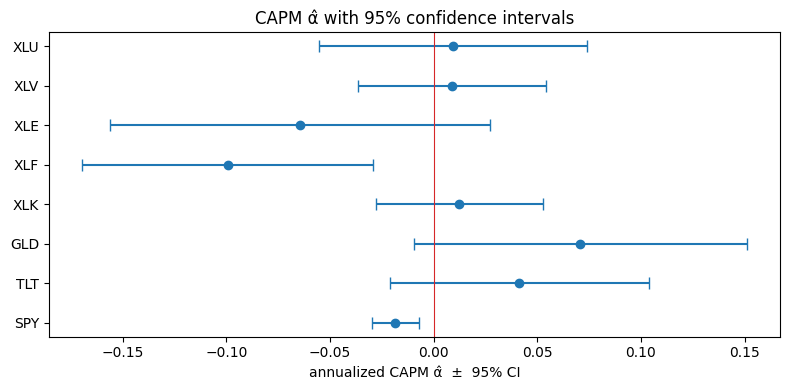

In [6]:
ses = []
for t in capm.index:
    excess_y = (lr3[t] - rf).values
    X = sm.add_constant(mkt_rf.values)
    f = sm.OLS(excess_y, X).fit()
    ses.append(f.bse[0] * 252)
ses = np.array(ses)

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(capm))
ax.errorbar(capm["alpha_ann"].values, y, xerr=1.96 * ses, fmt="o", capsize=4)
ax.axvline(0, color="C3", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(capm.index)
ax.set_xlabel("annualized CAPM α̂  ±  95% CI")
ax.set_title("CAPM α̂ with 95% confidence intervals")
fig.tight_layout(); plt.show()

**Reading the picture.** Most error bars cross zero — six of the eight assets have α̂ statistically indistinguishable from zero at 95% over 20 years.

**The two exceptions** in this window:
- **SPY** has small negative α̂ (≈ −1.8%, t ≈ −3.2) because SPY isn't the CRSP-defined market exactly — see §2.1. *Mostly an artifact.*
- **XLF** has large negative α̂ (≈ −10%, t ≈ −2.8) — financials *underperformed* the market on a β-adjusted basis. *Real.* The high β (1.28) meant XLF outperformed in raw returns during equity bull runs, but the 2008 collapse plus weak post-crisis growth left it with a negative β-adjusted return over the full window.

The textbook headline — "almost no asset has CAPM-α statistically distinguishable from zero" — is *mostly* true, but with notable exceptions. **The burden of proof for α is high — and the assets that clear the bar tend to clear it on the *negative* side, not the positive one.** This is a sceptical-investor's lesson: claims of *positive* α are rarer and less robust than claims of *negative* α.

## 5. Hidden factor exposure — Chapter 3 §3.5's promise paid off

Chapter 3 §3.5 deferred a question: *the 8-asset basket has weighted-average ρ ≈ 0.45 — but how much "diversification" does that actually represent?* CAPM gives us the tool to say *how much*: compute the basket's weighted-average β under common allocations.

In [7]:
import scipy.optimize as opt

ew8         = pd.Series(1/8, index=tickers)
sixty_forty = pd.Series({"SPY": 0.6, "TLT": 0.4}).reindex(tickers).fillna(0.0)
betas_s     = capm["beta"]

# Recompute Ch6-style GMV-LO and Tangency-LO weights for portfolio-beta context
mu_ann   = (log_returns.mean() * 252).values
cov_ann  = (log_returns.cov() * 252).values
rf_avg   = rf.mean() * 252
n        = len(tickers)
w0       = np.ones(n) / n
cons     = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
bnds     = [(0.0, 1.0)] * n

def neg_sharpe(w, mu, cov, rf_): return -((w @ mu) - rf_) / np.sqrt(w @ cov @ w)
def port_var(w, cov):            return float(w @ cov @ w)

w_tan = pd.Series(opt.minimize(neg_sharpe, w0, args=(mu_ann, cov_ann, rf_avg), method="SLSQP", bounds=bnds, constraints=cons).x, index=tickers)
w_gmv = pd.Series(opt.minimize(port_var,   w0, args=(cov_ann,),            method="SLSQP", bounds=bnds, constraints=cons).x, index=tickers)

print(f"EW8 weighted β:        {(ew8 * betas_s).sum():.3f}")
print(f"60/40 weighted β:      {(sixty_forty * betas_s).sum():.3f}")
print(f"GMV-LO weighted β:     {(w_gmv * betas_s).sum():.3f}")
print(f"Tangency-LO weighted β:{(w_tan * betas_s).sum():.3f}")

# Model-free check: regress EW8 portfolio daily returns on SPY
ew8_returns = log_returns[tickers].dot(ew8)
fE = sm.OLS(ew8_returns.values, sm.add_constant(log_returns["SPY"].values)).fit()
print(f"R^2 of EW8 daily returns on SPY: {fE.rsquared:.3f}")

EW8 weighted β:        0.690
60/40 weighted β:      0.490
GMV-LO weighted β:     0.202
Tangency-LO weighted β:0.422
R^2 of EW8 daily returns on SPY: 0.897


**The 8-asset basket has a lot more market exposure than its surface diversification suggests.** EW8's weighted β is about 0.69 — *not* the 0.85-0.95 you might expect for an "8-asset diversified" portfolio. Why? Because TLT (β = −0.24) and GLD (β = +0.06) at 1/8 each pull the average down hard. **The five sector ETFs (XLK, XLF, XLE, XLV, XLU) all carry β at or above 0.6 and provide essentially zero "diversification" in the factor-model sense — they're just different slices of the same market exposure.**

**The R² of EW8 on SPY is about 0.90**: ninety percent of the basket's daily-return variance is the market. Where does the remaining β-reduction come from? Almost entirely from TLT and GLD.

**This is Chapter 3 §3.5's promised answer.** "Diversification across sectors" is largely *not* diversification across factors. **GMV-LO** (heavily TLT) brings the weighted β down to 0.20 — the only weighting that meaningfully reduces market exposure does so by reaching outside equities. **Tangency-LO** (no SPY/sector concentration; heavy on XLK + GLD + TLT + XLV) is around 0.42 — also β-reduced, also driven by the non-equity sleeves. To meaningfully reduce factor exposure you need bonds, gold, or genuinely uncorrelated alternative betas — not more equity sectors.

## 6. Fama-French 3-factor — adding size and value

Two factors join the market in FF3:

> **SMB** (Small Minus Big) — *size factor.* The daily return of a portfolio long small-cap stocks and short large-cap stocks. Positive on days small caps beat large caps.
>
> **HML** (High Minus Low) — *value factor.* The daily return of a portfolio long high-book-to-market (value) stocks and short low (growth) stocks. Positive on days value beats growth.

The regression is now Ch7's multiple-regression form:

> R<sub>i,t</sub> − r<sub>f,t</sub> = α<sub>i</sub> + β<sub>mkt</sub>·(Mkt-RF)<sub>t</sub> + β<sub>SMB</sub>·SMB<sub>t</sub> + β<sub>HML</sub>·HML<sub>t</sub> + ε<sub>i,t</sub>

In [8]:
rows = []
for t in tickers:
    excess_y = (lr3[t] - rf).values
    Xf = sm.add_constant(ff3[["Mkt-RF", "SMB", "HML"]].values)
    f = sm.OLS(excess_y, Xf).fit()
    rows.append({
        "asset":     t,
        "b_mkt":     f.params[1],
        "b_smb":     f.params[2],
        "b_hml":     f.params[3],
        "alpha_ann": f.params[0] * 252,
        "t(alpha)":  f.tvalues[0],
        "R^2":       f.rsquared,
    })
ff3_table = pd.DataFrame(rows).set_index("asset")
print(ff3_table.round({"b_mkt": 3, "b_smb": 3, "b_hml": 3, "alpha_ann": 4, "t(alpha)": 2, "R^2": 3}))

       b_mkt  b_smb  b_hml  alpha_ann  t(alpha)    R^2
asset                                                 
SPY    0.987 -0.125  0.001    -0.0208     -4.13  0.987
TLT   -0.224  0.055 -0.199     0.0390      1.25  0.130
GLD    0.061  0.044 -0.113     0.0697      1.71  0.011
XLK    1.110 -0.141 -0.369     0.0037      0.21  0.887
XLF    1.208 -0.164  0.922    -0.0869     -3.75  0.881
XLE    1.051 -0.014  0.630    -0.0541     -1.25  0.598
XLV    0.705 -0.120 -0.107     0.0048      0.21  0.644
XLU    0.622 -0.298  0.068     0.0049      0.15  0.421


**Reading the FF3 table.** Compared to the CAPM table:

- **β<sub>SMB</sub>** is small and slightly negative for most sector ETFs (these are large-cap-heavy by construction; XLU's −0.30 is the most pronounced large-cap tilt).
- **β<sub>HML</sub>** is the most informative single column:
  - **XLF +0.92** — financials are heavily *value-tilted*. Banks have high book-to-market. (+0.92 is enormous — typical equity HML loadings sit in [−0.3, +0.3]; +0.9 means XLF moves with the value factor nearly 1-for-1.)
  - **XLE +0.63** — energy is also value-tilted. Capital-intensive, traditional industries.
  - **XLK −0.37** — tech is *growth-tilted*. Low book-to-market, high price-to-something multiples.
  - **TLT −0.20, GLD −0.11** — modest growth tilts (mostly noise; bonds and gold aren't really equity factors).
  - **SPY ≈ 0, XLV ≈ −0.11, XLU ≈ +0.07** — neutral/small.
- **α̂** generally *shrinks in magnitude* compared to CAPM. The SMB and HML loadings absorb part of what was previously in α + ε.

### 6.1 The XLK headline

XLK's CAPM α was small and not significant (+1.25%, t = 0.61). Under FF3 it shrinks to **+0.37%, t = 0.21** — even less significant — and R² rises from 0.84 to 0.89. **The clean canonical α-shrinkage demonstration:** XLK's apparent (already-statistically-zero) outperformance has a natural factor explanation — its growth tilt, captured by β<sub>HML</sub> = −0.37. Tech outperformed *because* growth outperformed, not because of stockpicking skill.

### 6.2 The XLF headline

XLF's CAPM α was a sharply negative −9.94% with t = −2.78. Under FF3, **the point estimate shrinks slightly (|α̂| 9.94% → 8.69%) but the t-statistic becomes more extreme (|t| 2.78 → 3.75) because residual noise drops faster than α̂ does — R² jumps 0.72 → 0.88. Even controlling for value-tilt, financials underperformed.** The huge β<sub>HML</sub> = +0.92 reveals that financials' negative α can't be explained away by their value-tilt; even controlling for SMB and HML, financials had a *real* negative β-adjusted return over the window. **This is what statistically robust negative α looks like.**

## 7. FF5 lightly — adding profitability and investment

FF5 adds two more factors:

> **RMW** (Robust Minus Weak) — *profitability factor.* Long high-profitability firms, short low.
>
> **CMA** (Conservative Minus Aggressive) — *investment factor.* Long firms with conservative (low) investment growth, short aggressive.

We demonstrate FF5 on **XLK only** as one regression — running the per-asset table for FF5 doubles the chapter length without adding a new lesson.

In [9]:
excess_xlk = (lr5["XLK"] - ff5["RF"]).values
Xf5 = sm.add_constant(ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].values)
f5 = sm.OLS(excess_xlk, Xf5).fit()
print(f5.summary())

excess_xlk_3 = (lr3["XLK"] - rf).values
Xf3 = sm.add_constant(ff3[["Mkt-RF", "SMB", "HML"]].values)
f3 = sm.OLS(excess_xlk_3, Xf3).fit()
print(f"\nXLK FF3 alpha annualized: {f3.params[0] * 252:.4f}")
print(f"XLK FF5 alpha annualized: {f5.params[0] * 252:.4f}")
print(f"FF3 R^2: {f3.rsquared:.4f}")
print(f"FF5 R^2: {f5.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     7939.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        11:33:32   Log-Likelihood:                 19591.
No. Observations:                5006   AIC:                        -3.917e+04
Df Residuals:                    5000   BIC:                        -3.913e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.083e-06   6.84e-05      0.089      0.9

The marginal R² of FF5 over FF3 on XLK is small — typically a few thousandths (0.887 → 0.888 in this fit). XLK's α moves from +0.37% to +0.15% — both indistinguishable from zero. β<sub>RMW</sub> = +0.06 (slight profitability tilt — tech firms earn well) and β<sub>CMA</sub> = −0.02 (slight aggressive-investment tilt). **FF5 matters more on individual stocks with cleaner factor exposures than on diversified ETFs.**

For a curriculum focused on diversified ETFs, FF3 is the workhorse model and FF5 is the named-only refinement. The Carhart 4-factor (adds momentum), the Q-factor, and the AQR-style models live in the **factor zoo** named in §8 — out of scope here.

## 8. Limits — five caveats

**1. The factor zoo.** The literature has produced hundreds of "factors" since Fama-French (1992). Most don't survive replication. The empirical-finance toolkit is much smaller than the publication record suggests.

**2. Factor crowding.** Once a factor is well-known and trading capital flows to it, expected return drops. Decade-by-decade R² and α̂ of FF3 are not stable through time.

**3. Factor timing.** Factor returns themselves are time-varying. HML had a brutal 2010s. The CAPM/FF framework treats β and the factor premia as constants; reality has regimes.

**4. Ex-post selection.** Factors selected on what worked in-sample are biased upward. The honest test is *out-of-sample, post-publication* — disappointing for many "discovered" factors.

**5. β is regime-dependent.** A 20-year point estimate of β is not the right number for sizing a position today. Rolling-window β, or properly time-varying β via GARCH-style models, is closer to honest. **Chapter 9** introduces the machinery.

## 9. Recap by flavor

- **CAPM** — single market factor; clean conceptually, but α has wide CIs and *most* (six of eight here) is noise.
- **Fama-French 3** — adds size and value; absorbs some apparent CAPM α (XLK shrinks to nothing); *the* canonical model in academic empirical asset pricing.
- **FF5** — adds profitability and investment; marginal R² gains on diversified ETFs; useful at the individual-stock level.
- **The 8-asset basket** is essentially a one-factor object — diversification across "different sectors" is mostly sharing the market factor (R² of EW8 on SPY ≈ 0.90).
- **α is mostly noise — but "mostly" isn't "always".** Two of eight assets show statistically distinguishable α at 95% in this window, and *both are negative*. Claims of *positive* α are even rarer.

## 10. So what?

**Decision rules:**

- **Always run CAPM (or better, FF3) on a candidate strategy or asset before reporting raw returns.** Strip out market β and known factors; what's left in α + ε is the only candidate for "real."
- **t(α̂) is the headline.** Skeptical bar: t > 3 (because we test many strategies). Conventional bar: t > 2 (still doesn't survive multiple-comparison correction).
- **β tells you risk; α (if real) tells you skill.** They are *different statistics.* Don't average them.
- **Add factors to FF3 only with a story.** Otherwise it's data-mining.
- **β changes over time.** Use rolling-window estimates or GARCH-β (Ch9), not 20-year point estimates, for live-trading decisions.

**What this chapter can't yet tell you:**

- How β changes through time. Rolling β / GARCH-β → **Chapter 9.**
- How tail dependence interacts with β. **Chapter 10.**
- Whether your candidate strategy survives transaction costs after factor-adjustment. **Chapter 13.**
- How to size positions given a β-adjusted α. **Future Chapter 12** (Kelly).

## Key Terms

| Term | Definition |
|---|---|
| Factor | A common driver of asset returns (market, size, value, profitability, etc.). |
| Factor exposure / loading | The β coefficient on a factor in a regression. |
| Systematic risk | Risk explained by factors common to many assets. |
| Idiosyncratic risk | Asset-specific residual risk after factor exposure is removed. |
| Market portfolio | The value-weighted basket of all risky assets; in practice proxied by SPY *or* — for academic work — the CRSP value-weighted Mkt-RF series. |
| Market risk premium | E[R<sub>mkt</sub> − r<sub>f</sub>]; expected reward for bearing market risk. |
| β (beta) | Slope on a factor; quantifies systematic exposure. |
| α (alpha) | Regression intercept; the unexplained-by-factors residual mean. |
| CAPM | Capital Asset Pricing Model — single-factor (market) model. |
| Fama-French 3-factor model (FF3) | Market + SMB + HML. |
| Fama-French 5-factor model (FF5) | FF3 + RMW + CMA. |
| SMB | Small Minus Big — size factor. |
| HML | High Minus Low — value (book-to-market) factor. |
| RMW | Robust Minus Weak — profitability factor. |
| CMA | Conservative Minus Aggressive — investment factor. |
| Factor zoo (named) | The proliferation of published factors; most fail replication. |
| Ken French data library | Dartmouth-hosted source for academic factor data. |
| Excess return | Return over the risk-free rate (refresh from Ch5). |

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **CAPM β stability over time.** For XLF and XLK, plot the rolling 252-day CAPM β over the full window. How much does β move? Are the swings larger in one sector than the other, and what economic story explains the difference?

2. **Build your own size-tilt.** Without using Ken French data, regress XLK's excess return on Mkt-RF and on (IWM − SPY) where IWM is the Russell 2000 ETF. How does the (IWM − SPY) coefficient compare to FF3's β<sub>SMB</sub>? Why might a homemade factor differ in magnitude from the academic one even when the sign agrees?

3. **α confidence-interval audit.** From §6's FF3 table, compute the 95% CI for each asset's annualized α̂. Which (if any) exclude zero? Did any asset's CAPM-α-significant become FF3-α-insignificant?

4. *(stretch)* **Portfolio β decomposition.** For Ch6's long-only tangency portfolio, regress the portfolio's daily excess returns on FF3 and decompose its variance into Mkt / SMB / HML / residual contributions. What does the decomposition say about whether tangency-portfolio construction implicitly diversifies across factors?


End of notebook. Read the chapter [`README.md`](./README.md) for the canonical narrative.